# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** [Jadzia Afia Ohenewaa Mantey]
**Student ID:** [23672028]

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [34]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

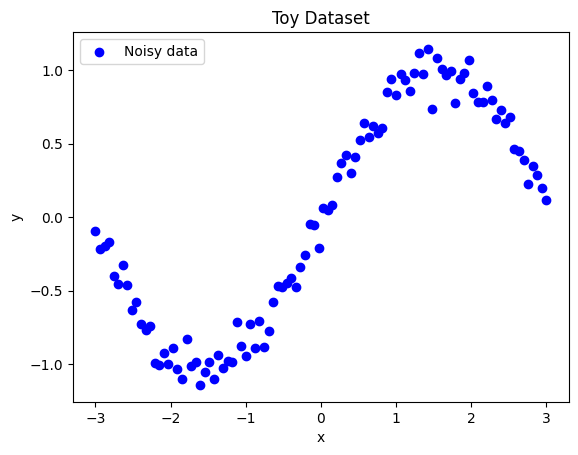

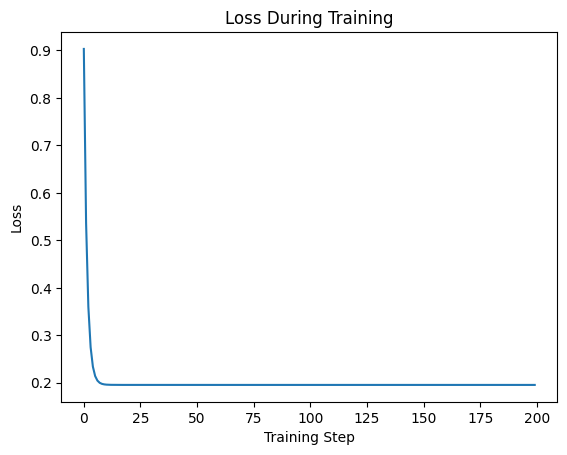

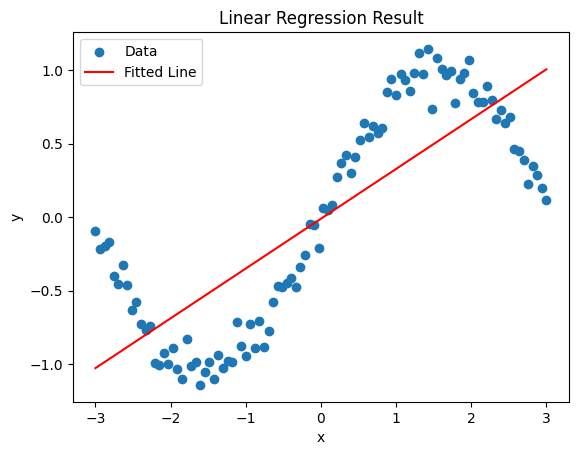

Final weight (w): 0.3390328433849219
Final bias (b): -0.010384651761759827
Final loss: 0.1954517971396205


In [35]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.

# TODO: Initialise w and b to small random values.

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.

# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.

import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Step 1: Create the data
# -------------------------

# Make the random numbers the same every time we run the code
np.random.seed(42)

# Create 100 x-values from -3 to 3
x = np.linspace(-3, 3, 100)

# Create y-values using sin(x) and add a little random noise
y = np.sin(x) + np.random.normal(0, 0.1, 100)

# Plot the data
plt.scatter(x, y, color="blue", label="Noisy data")
plt.title("Toy Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


# -------------------------
# Step 2: Initialize w and b
# -------------------------

# Start with small random values
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1

# Learning rate
lr = 0.05

# Number of training steps
epochs = 200

# Store the loss after each step
losses = []


# -------------------------
# Step 3: Train the model
# -------------------------

for i in range(epochs):

    # Predict y using the equation y = wx + b
    y_hat = w * x + b

    # Calculate Mean Squared Error (MSE)
    loss = np.mean((y_hat - y) ** 2)

    # Save the loss
    losses.append(loss)

    # Calculate the gradients
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    # Update w and b
    w = w - lr * dw
    b = b - lr * db


# -------------------------
# Step 4: Plot the loss
# -------------------------

plt.plot(losses)
plt.title("Loss During Training")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.show()


# -------------------------
# Step 5: Plot the fitted line
# -------------------------

# Final prediction
y_hat = w * x + b

plt.scatter(x, y, label="Data")
plt.plot(x, y_hat, color="red", label="Fitted Line")
plt.legend()
plt.title("Linear Regression Result")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


# Print the final values
print("Final weight (w):", w)
print("Final bias (b):", b)
print("Final loss:", losses[-1])

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:** 2.t is underfitting, because the model is too simple to capture the complexity of the data. A longer training time would only find a slightly better straight line.

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

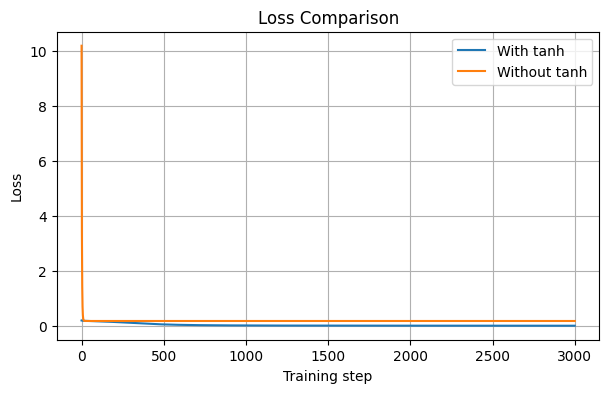

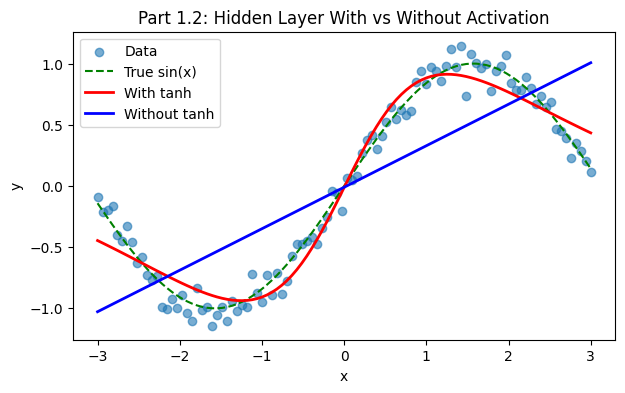

In [36]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
#   h  = np.tanh(z1)        # activation
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
#   loss  = np.mean((y_hat - y) ** 2)

# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.

# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
import numpy as np
import matplotlib.pyplot as plt


# ==================================
# Create the toy data
# ==================================

np.random.seed(42)

x = np.linspace(-3, 3, 100).reshape(-1, 1)

# y = sin(x) + noise
y = np.sin(x) + np.random.normal(0, 0.1, x.shape)


# ==================================
# Function to train the network
# ==================================

def train(use_tanh=True):

    # ------------------------------
    # Initialise parameters
    # ------------------------------

    # Input -> Hidden (8 neurons)
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros(8)

    # Hidden -> Output
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros(1)


    lr = 0.01
    steps = 3000

    losses = []


    # ------------------------------
    # Training loop
    # ------------------------------

    for step in range(steps):

        # Forward pass

        z1 = x @ W1 + b1


        # Use tanh activation or remove it
        if use_tanh:
            h = np.tanh(z1)
        else:
            h = z1


        y_hat = h @ W2 + b2


        # Calculate loss
        loss = np.mean((y_hat - y) ** 2)

        losses.append(loss)



        # --------------------------
        # Backward pass
        # --------------------------

        d_yhat = 2 * (y_hat - y) / len(y)


        # Output layer
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)


        # Hidden layer
        dh = d_yhat @ W2.T


        if use_tanh:

            # derivative of tanh
            dz1 = dh * (1 - np.tanh(z1) ** 2)

        else:

            # derivative when h = z1
            dz1 = dh



        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)



        # --------------------------
        # Update parameters
        # --------------------------

        W1 -= lr * dW1
        b1 -= lr * db1

        W2 -= lr * dW2
        b2 -= lr * db2



    # Final prediction

    z1 = x @ W1 + b1

    if use_tanh:
        h = np.tanh(z1)
    else:
        h = z1

    y_hat = h @ W2 + b2


    return losses, y_hat



# ==================================
# Train with tanh
# ==================================

loss_tanh, y_tanh = train(use_tanh=True)



# ==================================
# Train without tanh
# ==================================

loss_no_tanh, y_no_tanh = train(use_tanh=False)



# ==================================
# Plot loss curves
# ==================================

plt.figure(figsize=(7,4))

plt.plot(loss_tanh, label="With tanh")
plt.plot(loss_no_tanh, label="Without tanh")

plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Loss Comparison")

plt.legend()
plt.grid()
plt.show()



# ==================================
# Plot final fits
# ==================================

plt.figure(figsize=(7,4))

plt.scatter(x, y, label="Data", alpha=0.6)

plt.plot(x, np.sin(x),
         color="green",
         linestyle="--",
         label="True sin(x)")


plt.plot(x, y_tanh,
         color="red",
         linewidth=2,
         label="With tanh")


plt.plot(x, y_no_tanh,
         color="blue",
         linewidth=2,
         label="Without tanh")


plt.xlabel("x")
plt.ylabel("y")
plt.title("Part 1.2: Hidden Layer With vs Without Activation")

plt.legend()
plt.show()

**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:** 2. The 8 hidden neurons created different nonlinear features of the input.

3. Backpropagation is the proccess of using the chain rule to calculate how much each network parameter contributed to the error so the weights can be updated to reduce the loss.

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_394/2282891985.py:52: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y) ** 2)
/tmp/ipykernel_394/2282891985.py:68: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
/tmp/ipykernel_394/2282891985.py:70: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


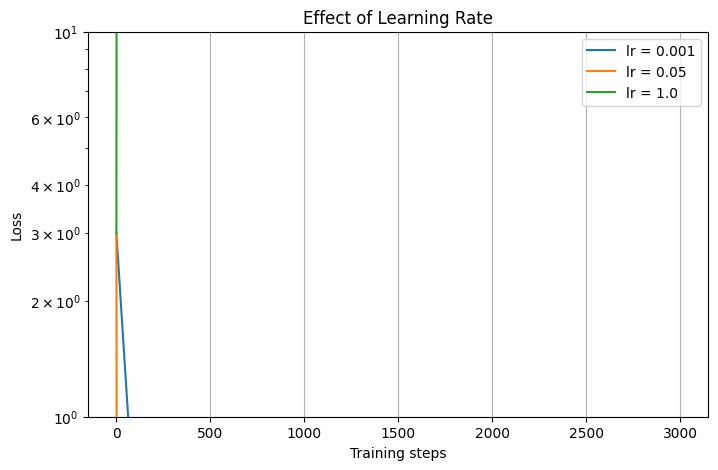

In [37]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
import numpy as np
import matplotlib.pyplot as plt




np.random.seed(42)

x = np.linspace(-3, 3, 100).reshape(-1, 1)
y = np.sin(x) + np.random.normal(0, 0.1, x.shape)





def train_toy(lr, steps=3000):

    # Reset seed so all learning rates
    # start with the same weights
    np.random.seed(123)

    # Initialise parameters
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros(8)

    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros(1)


    losses = []


    # Training loop
    for step in range(steps):



        z1 = x @ W1 + b1
        h = np.tanh(z1)

        y_hat = h @ W2 + b2


        # Loss
        loss = np.mean((y_hat - y) ** 2)

        losses.append(loss)




        d_yhat = 2 * (y_hat - y) / len(y)


        # Output layer
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)


        # Hidden layer
        dh = d_yhat @ W2.T

        dz1 = dh * (1 - np.tanh(z1) ** 2)

        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)




        W1 -= lr * dW1
        b1 -= lr * db1

        W2 -= lr * dW2
        b2 -= lr * db2


    return losses





loss_small = train_toy(lr=0.001)

loss_good = train_toy(lr=0.05)

loss_large = train_toy(lr=1.0)





plt.figure(figsize=(8,5))

plt.plot(loss_small, label="lr = 0.001")
plt.plot(loss_good, label="lr = 0.05")
plt.plot(loss_large, label="lr = 1.0")


plt.xlabel("Training steps")
plt.ylabel("Loss")
plt.title("Effect of Learning Rate")

# Log scale makes differences easier to see
plt.yscale("log")

plt.legend()
plt.grid()

plt.show()

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:** first curve[Learning rate = 0.001] The loss decreases very slowly.
The model is learning, but each update to the weights is tiny and it would require many more training steps to reach a good solution.

second curve[Learning rate = 0.05]The loss decreases quickly and smoothly.
The model makes useful updates without overshooting and training converges to a lower loss

thrd curve[Learning rate = 1.0]The loss may jump up and down or increase.
The model does not settle on a good solution.
The updates are too large, causing unstable training.

2. The model is not learning faster because if the step is too large, the model loses the ability to make controlled progress and training becomes unstable.

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [38]:
import pandas as pd
import zipfile
import io
import requests

OBESITY_URL = "https://archive.ics.uci.edu/static/public/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition.zip"

# Download zip file
response = requests.get(OBESITY_URL)
response.raise_for_status()

# Open zip directly from memory
with zipfile.ZipFile(io.BytesIO(response.content)) as z:

    print(z.namelist())  # check files inside

    # Load the CSV
    with z.open("ObesityDataSet_raw_and_data_sinthetic.csv") as f:
        obesity = pd.read_csv(f)


print(obesity.shape)
print(obesity.head())
print(obesity.columns)

['ObesityDataSet_raw_and_data_sinthetic.csv']
(2111, 17)
   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportatio

In [39]:
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).

# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.

# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)

# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader
import pandas as pd
import numpy as np
import requests
import io

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

import torch
from torch.utils.data import TensorDataset, DataLoader

OBESITY_URL = "https://archive.ics.uci.edu/static/public/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition.zip"

# Download zip file
response = requests.get(OBESITY_URL)
response.raise_for_status()

# Open zip directly from memory
with zipfile.ZipFile(io.BytesIO(response.content)) as z:

    print(z.namelist())  # check files inside

    # Load the CSV
    with z.open("ObesityDataSet_raw_and_data_sinthetic.csv") as f:
        obesity = pd.read_csv(f)


print(obesity.shape)
print(obesity.head())
print(obesity.columns)



# Binary yes/no columns
binary_cols = [
    "family_history_with_overweight",
    "FAVC",
    "SMOKE",
    "SCC"
]

for col in binary_cols:
    obesity[col] = obesity[col].map({
        "yes": 1,
        "no": 0
    })


# Gender (binary)
obesity["Gender"] = obesity["Gender"].map({
    "Male": 1,
    "Female": 0
})


# Multi-class categorical columns
# One-hot encoding avoids creating false ordering
categorical_cols = [
    "MTRANS",
    "CAEC",
    "CALC"
]

obesity = pd.get_dummies(
    obesity,
    columns=categorical_cols,
    drop_first=False
)




target = "NObeyesdad"

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(
    obesity[target]
)

# Remove target from features
X = obesity.drop(columns=[target])


print("Classes:")
print(label_encoder.classes_)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)





RANDOM_STATE = 42


# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)


# Second split: 60% train, 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_temp
)


print(
    f"Train: {X_train.shape[0]}, "
    f"Validation: {X_val.shape[0]}, "
    f"Test: {X_test.shape[0]}"
)





scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)




X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)


y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)




train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)


train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)


print("DataLoaders ready!")

['ObesityDataSet_raw_and_data_sinthetic.csv']
(2111, 17)
   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportatio

**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:** 1. CrossEntropyLoss in PyTorch expects the target to be the class index (an integer), not a one-hot encoded vectors.

2. The large-scale features create larger gradient updates, while smaller-scale features may barely affect the weights.

This can cause:

unstable training,
slower convergence,
difficulty choosing a good learning rate.After scalig, features have similar ranges, so the gradients are more balanced and the network can learn more effectivel.

3. shuffle=True randomly changes the order of training examples at the start of each epoch.

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [40]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

# class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
#     def forward(self, x):
#         ...

# TODO: Instantiate, move to DEVICE, print the model.

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.

import torch
import torch.nn as nn




class FeedForwardNet(nn.Module):

    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super().__init__()

        self.network = nn.Sequential(

            # Hidden layer 1
            nn.Linear(input_dim, hidden_sizes[0]),
            nn.ReLU(),

            # Hidden layer 2
            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(),

            # Output layer: 7 raw logits
            nn.Linear(hidden_sizes[1], n_classes)
        )


    def forward(self, x):
        return self.network(x)





input_dim = X_train.shape[1]

model = FeedForwardNet(
    input_dim=input_dim,
    hidden_sizes=(64, 32),
    n_classes=7
)


# Move model to device
model = model.to(DEVICE)


# Print model structure
print(model)





trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Trainable parameters:", trainable_params)





first_layer_count = input_dim * 64 + 64

print("First layer parameters:", first_layer_count)

FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=26, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
Trainable parameters: 4039
First layer parameters: 1728


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:** 2. ReLU reduces the vanishing gradient problem because its gradient is 1 for positive inputs, alllowing gradients to flow more easily through many layers.

3.he network is only a linear model, no matter how many layers it has without ReLU

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Epoch 01/50 | Train Loss: 1.7325 | Val Loss: 1.7354 | Train Acc: 0.544 | Val Acc: 0.514
Epoch 02/50 | Train Loss: 1.3640 | Val Loss: 1.3785 | Train Acc: 0.585 | Val Acc: 0.555
Epoch 03/50 | Train Loss: 1.0135 | Val Loss: 1.0416 | Train Acc: 0.650 | Val Acc: 0.628
Epoch 04/50 | Train Loss: 0.8167 | Val Loss: 0.8609 | Train Acc: 0.742 | Val Acc: 0.718
Epoch 05/50 | Train Loss: 0.6893 | Val Loss: 0.7428 | Train Acc: 0.783 | Val Acc: 0.756
Epoch 06/50 | Train Loss: 0.5864 | Val Loss: 0.6574 | Train Acc: 0.820 | Val Acc: 0.775
Epoch 07/50 | Train Loss: 0.5073 | Val Loss: 0.5882 | Train Acc: 0.838 | Val Acc: 0.789
Epoch 08/50 | Train Loss: 0.4415 | Val Loss: 0.5249 | Train Acc: 0.863 | Val Acc: 0.822
Epoch 09/50 | Train Loss: 0.3893 | Val Loss: 0.4802 | Train Acc: 0.882 | Val Acc: 0.822
Epoch 10/50 | Train Loss: 0.3432 | Val Loss: 0.4345 | Train Acc: 0.919 | Val Acc: 0.855
Epoch 11/50 | Train Loss: 0.2999 | Val Loss: 0.4017 | Train Acc: 0.923 | Val Acc: 0.863
Epoch 12/50 | Train Loss: 0.2677

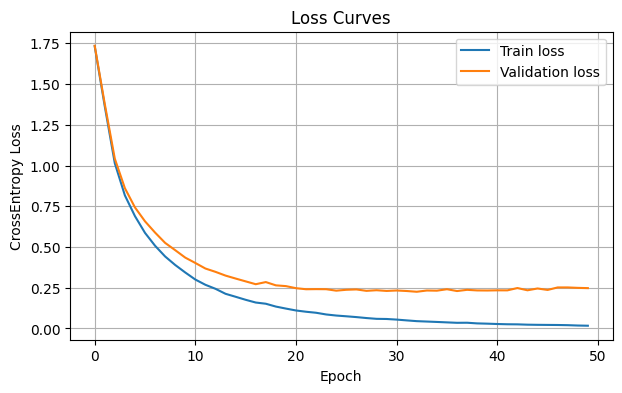

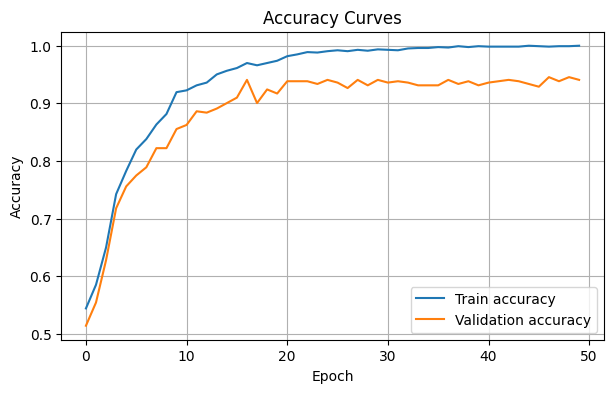

In [41]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify

# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.

# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.
import torch
import torch.nn as nn
import matplotlib.pyplot as plt




criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)




epochs = 50

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}


best_val_acc = 0.0





for epoch in range(epochs):



    model.train()

    train_loss = 0.0


    for xb, yb in train_loader:

        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)


        # Clear previous gradients
        optimizer.zero_grad()


        # Forward pass
        logits = model(xb)


        # Compute loss
        loss = criterion(logits, yb)


        # Backpropagation
        loss.backward()


        # Update weights
        optimizer.step()


        train_loss += loss.item()



    train_loss /= len(train_loader)





    def evaluate(loader):

        model.eval()

        total_loss = 0.0
        correct = 0
        total = 0


        with torch.no_grad():

            for xb, yb in loader:

                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)


                logits = model(xb)

                loss = criterion(logits, yb)

                total_loss += loss.item()


                # Predicted class
                predictions = torch.argmax(
                    logits,
                    dim=1
                )


                correct += (
                    predictions == yb
                ).sum().item()

                total += yb.size(0)


        avg_loss = total_loss / len(loader)

        accuracy = correct / total


        return avg_loss, accuracy



    # Evaluate train and validation sets

    train_eval_loss, train_acc = evaluate(train_loader)

    val_loss, val_acc = evaluate(val_loader)



    # Store history

    history["train_loss"].append(train_eval_loss)
    history["val_loss"].append(val_loss)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)



    # Save best model

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "ffn_best.pt"
        )



    # Epoch summary

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train Loss: {train_eval_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.3f} | "
        f"Val Acc: {val_acc:.3f}"
    )





plt.figure(figsize=(7,4))

plt.plot(
    history["train_loss"],
    label="Train loss"
)

plt.plot(
    history["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("CrossEntropy Loss")
plt.title("Loss Curves")

plt.legend()
plt.grid()

plt.show()





plt.figure(figsize=(7,4))

plt.plot(
    history["train_acc"],
    label="Train accuracy"
)

plt.plot(
    history["val_acc"],
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")

plt.legend()
plt.grid()

plt.show()

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:** 3. optimizer.zero_grad() must be called before every batch so that each updates uses only the grdient from the current batch

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

In [42]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.
import torch
import torch.nn as nn
import matplotlib.pyplot as plt




class FeedForwardNet(nn.Module):

    def __init__(self, input_dim, hidden_sizes=(64,32), n_classes=7, dropout=0.0):
        super().__init__()

        layers = []

        prev_dim = input_dim

        for hidden_dim in hidden_sizes:

            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            prev_dim = hidden_dim


        # Output layer
        layers.append(nn.Linear(prev_dim, n_classes))

        self.network = nn.Sequential(*layers)


    def forward(self, x):
        return self.network(x)





def run_experiment(
    hidden_sizes=(64,32),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.0
):

    # New model
    model = FeedForwardNet(
        input_dim=X_train.shape[1],
        hidden_sizes=hidden_sizes,
        dropout=dropout
    ).to(DEVICE)


    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )


    # DataLoaders with chosen batch size
    train_loader_exp = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader_exp = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )


    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }


    for epoch in range(epochs):



        model.train()

        for xb, yb in train_loader_exp:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)


            optimizer.zero_grad()

            logits = model(xb)

            loss = criterion(logits, yb)

            loss.backward()

            optimizer.step()





        def evaluate(loader):

            model.eval()

            total_loss = 0
            correct = 0
            total = 0


            with torch.no_grad():

                for xb, yb in loader:

                    xb = xb.to(DEVICE)
                    yb = yb.to(DEVICE)


                    logits = model(xb)

                    loss = criterion(logits, yb)

                    total_loss += loss.item()


                    pred = torch.argmax(
                        logits,
                        dim=1
                    )

                    correct += (
                        pred == yb
                    ).sum().item()

                    total += yb.size(0)


            return (
                total_loss / len(loader),
                correct / total
            )


        train_loss, train_acc = evaluate(train_loader_exp)

        val_loss, val_acc = evaluate(val_loader_exp)


        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)



    return history

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:**
1.he largest network (256,128,64) may achieve the highest training accuracy, but if its validation accuracy stops improving or decreases, this indicates overfitting.

Diminishing returns appear when increasing the model size gives only a small improvement (or no improvement) in validation accuracy despite adding many more parameters.


2.Yes, the learning-rate behaviour is the same as the toy problem in Part 1.3.

3.Dropout reduced the gap between training and validation accuracy.


Dropout works by randomly turning off a fraction of neurons during training. This prevents neurons from relying too heavily on specific features and forces the network to learn more robust patterns that generalise better to unseen data.



### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

Test Accuracy: 0.9291
Test Macro-F1: 0.9276
                     precision    recall  f1-score   support

Insufficient_Weight       0.95      0.98      0.96        54
      Normal_Weight       0.89      0.84      0.87        58
     Obesity_Type_I       0.93      0.96      0.94        70
    Obesity_Type_II       0.98      0.97      0.97        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.84      0.88      0.86        58
Overweight_Level_II       0.91      0.88      0.89        58

           accuracy                           0.93       423
          macro avg       0.93      0.93      0.93       423
       weighted avg       0.93      0.93      0.93       423



<Figure size 800x800 with 0 Axes>

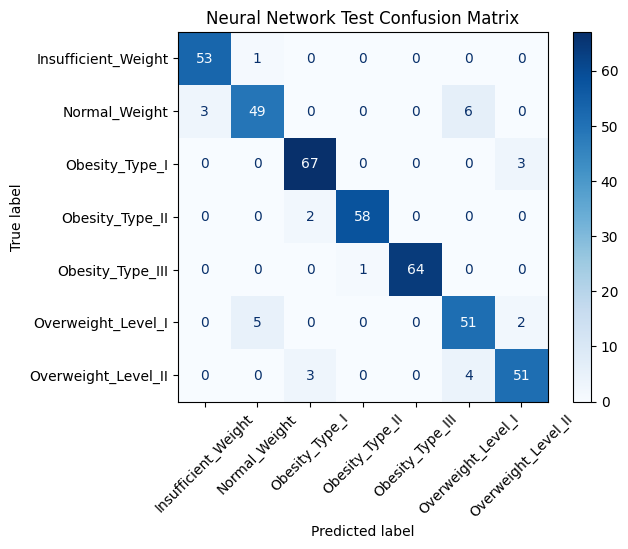

In [43]:
# TODO: Load your best configuration's weights; model.eval().

# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay

# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]

import torch
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix
)

import matplotlib.pyplot as plt




model.load_state_dict(
    torch.load("ffn_best.pt")
)

model = model.to(DEVICE)

model.eval()



# Store predictions

test_preds = []
test_labels = []

test_loss = 0.0


with torch.no_grad():

    for xb, yb in test_loader:

        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)


        logits = model(xb)


        preds = torch.argmax(
            logits,
            dim=1
        )


        test_preds.extend(
            preds.cpu().numpy()
        )

        test_labels.extend(
            yb.cpu().numpy()
        )





test_accuracy = accuracy_score(
    test_labels,
    test_preds
)


test_macro_f1 = f1_score(
    test_labels,
    test_preds,
    average="macro"
)


print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Macro-F1: {test_macro_f1:.4f}")


print(
    classification_report(
        test_labels,
        test_preds,
        target_names=label_encoder.classes_
    )
)





cm = confusion_matrix(
    test_labels,
    test_preds
)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)


plt.figure(figsize=(8,8))

disp.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Neural Network Test Confusion Matrix")

plt.show()

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** The confusion matrix shows that the neural network still struggles with classes that have the same features and patterns which are similar to those in lab2 since both models are learning from the same available features.

2.Deep learning was useful as a learning exercise and produced a competitive model, but the extra complexity may not be justified if it does not siginificantly improve test performance over the classical model.

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
  During the forward pass, PyTorch keeps track of the operations used to produce the loss using the loss.backward().

  the optimizer uses gradients to update and actually move the model weights.




2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
   I would choose the learning rate.The learning rate controls the size of every weight update during training, so it has a direct effect on whether the model learns efficiently.

3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
   The biggest train-validation gap appeared with the largest network:(256,128,64) without regularization

   The intervention that reduced the gap the most was dropout.

4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

   MLPs ignore the structure of images, while CNNs are designed to exploit the spatial relationships between pixels

>

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.